# Validation Results Inspection

Compares gyaradax outputs against GKW reference data for both adiabatic and kinetic electron cases.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
sys.path.append("..")

os.environ["CUDA_VISIBLE_DEVICES"] = ""

from gyaradax.bootstrap import init_jax
init_jax(device=6)

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/system/apps/userenv/galletti/mhd/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 497, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/system/apps/userenv/galletti/mhd/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 348, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/system/apps/userenv/galletti/mhd/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:126: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from gyaradax.plot_utils import (
    plot_flux_trace,
    plot_spectra,
    plot_growth_rates,
    plot_growth_snapshots,
    plot_ky_spectra_evolution,
)
from gyaradax.params import load_config
from gyaradax.utils import load_geometry

In [4]:
adiabatic_dirs = sorted(
    [d for d in os.listdir("..") if d.startswith("validation_outputs_")]
)
kinetic_dirs = sorted(
    [d for d in os.listdir("..") if d.startswith("validation_kinetic_")]
)
print(f"adiabatic: {adiabatic_dirs}")
print(f"kinetic: {kinetic_dirs}")

adiabatic: ['validation_outputs_iteration_13', 'validation_outputs_iteration_200']
kinetic: ['validation_kinetic_kinetic_991_half_rlt']


## 1. Adiabatic Flux Comparison
Single-species (ion) heat and momentum fluxes.

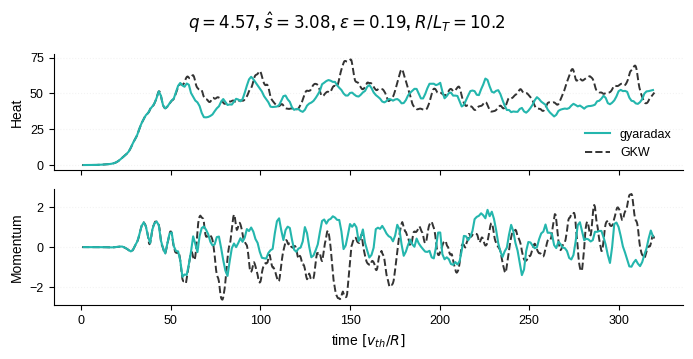

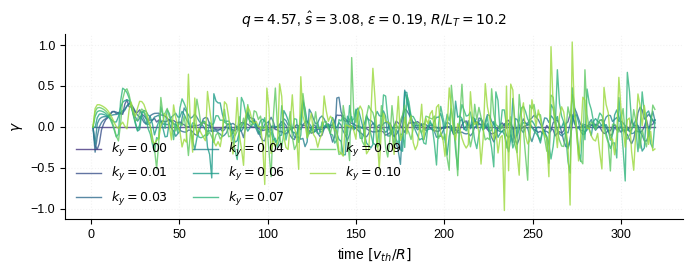

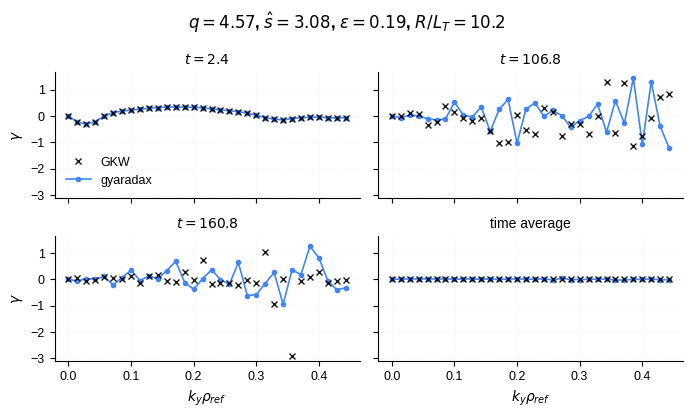

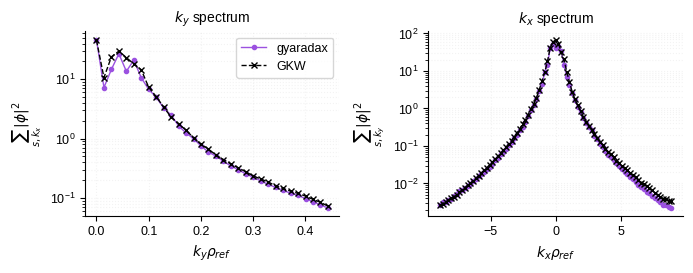

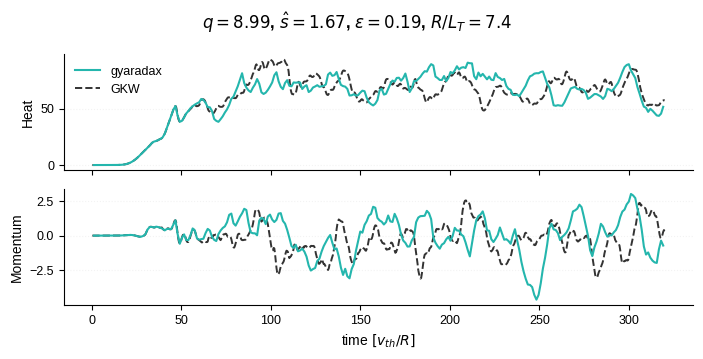

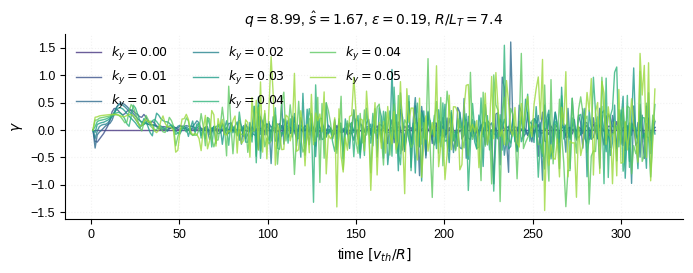

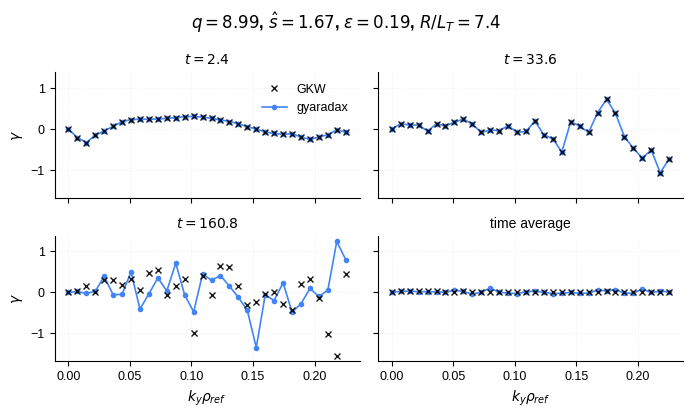

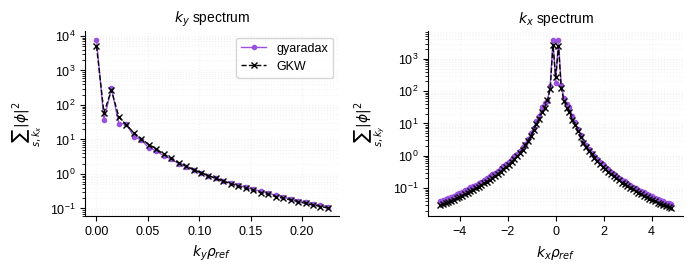

In [5]:
os.makedirs("figs", exist_ok=True)

for out_dir in adiabatic_dirs:
    path = os.path.join("..", out_dir)
    flux_path = os.path.join(path, "fluxes.npz")
    growth_path = os.path.join(path, "growth.npz")

    if not os.path.exists(flux_path) or not os.path.exists(growth_path):
        print(f"skipping {out_dir}: missing .npz files")
        continue

    sim_flux = np.load(flux_path)["fluxes"]
    growth_data = np.load(growth_path)
    sim_time = growth_data["time"]
    sim_growth = growth_data["growth"]

    config_name = out_dir.replace("validation_outputs_", "")
    config_path = os.path.join("..", "configs", f"{config_name}.yaml")

    ref_time, ref_fluxes = None, None
    kx, ky = None, None
    title = config_name
    ref_dir = None
    if os.path.exists(config_path):
        cfg = load_config(config_path)
        ref_dir = cfg.run.data_dir
        ref_time_path = os.path.join(ref_dir, "time.dat")
        ref_flux_path = os.path.join(ref_dir, "fluxes.dat")
        if os.path.exists(ref_time_path) and os.path.exists(ref_flux_path):
            ref_time = np.loadtxt(ref_time_path)
            ref_fluxes = np.loadtxt(ref_flux_path).T

        geom = load_geometry(ref_dir)
        kx = np.asarray(geom["kxrh"])
        ky = np.asarray(geom["krho"])

        q = float(geom["q"])
        shat = float(geom["shat"])
        eps = float(geom["eps"])
        rlt = float(np.asarray(geom["rlt"]).flat[0])
        title = (
            rf"$q={q:.2f}$, $\hat{{s}}={shat:.2f}$, "
            rf"$\varepsilon={eps:.2f}$, $R/L_T={rlt:.1f}$"
        )

    # fluxes
    fig = plot_flux_trace(
        sim_time,
        sim_flux.T[[1, 2]],
        ref_time=ref_time,
        ref_fluxes=ref_fluxes[[1, 2]] if ref_fluxes is not None else None,
        labels=["Heat", "Momentum"],
        title=title,
    )
    fig.savefig(f"figs/fluxes_{config_name}.pdf")
    plt.show()

    # per-ky growth rates (time series)
    if sim_growth.ndim == 2 and ky is not None:
        ref_time_dat = None
        if ref_dir:
            t_path = os.path.join(ref_dir, "time.dat")
            if os.path.exists(t_path):
                rd = np.loadtxt(t_path)
                if rd.ndim == 2 and rd.shape[1] >= 2:
                    ref_time_dat = rd

        fig_gr = plot_growth_rates(
            sim_time, sim_growth, ky=ky,
            ref_time=ref_time_dat, title=title,
        )
        fig_gr.savefig(f"figs/growth_{config_name}.pdf")
        plt.show()

        # 2x2 growth rate snapshots: gamma(ky) at 4 timesteps
        ref_growth_dat, ref_time_1d = None, None
        if ref_dir:
            gdat_path = os.path.join(ref_dir, "growth.dat")
            tdat_path = os.path.join(ref_dir, "time.dat")
            if os.path.exists(gdat_path) and os.path.exists(tdat_path):
                ref_growth_dat = np.loadtxt(gdat_path)
                ref_time_1d = np.loadtxt(tdat_path)
                if ref_time_1d.ndim == 2:
                    ref_time_1d = ref_time_1d[:, 0]

        fig_snap = plot_growth_snapshots(
            ky, sim_growth, sim_time,
            ref_growth=ref_growth_dat, ref_time=ref_time_1d,
            title=title,
        )
        fig_snap.savefig(f"figs/growth_snap_{config_name}.pdf")
        plt.show()

    # time-averaged spectra
    ky_spec_path = os.path.join(path, "kyspec.npz")
    kx_spec_path = os.path.join(path, "kxspec.npz")
    if (
        os.path.exists(kx_spec_path)
        and os.path.exists(ky_spec_path)
        and kx is not None
    ):
        avg_count = 80
        kx_spec_raw = np.load(kx_spec_path)["kx_spec"]
        ky_spec_raw = np.load(ky_spec_path)["ky_spec"]

        if kx_spec_raw.shape[-1] != len(kx) or ky_spec_raw.shape[-1] != len(ky):
            print(f"skipping spectra for {config_name}: shape mismatch")
            continue

        kx_spec_avg = np.mean(kx_spec_raw[-avg_count:], axis=0)
        ky_spec_avg = np.mean(ky_spec_raw[-avg_count:], axis=0)

        ref_kx_spec, ref_ky_spec = None, None
        if ref_dir:
            ref_kx_path = os.path.join(ref_dir, "kxspec")
            ref_ky_path = os.path.join(ref_dir, "kyspec")
            if os.path.exists(ref_kx_path) and os.path.exists(ref_ky_path):
                ref_kx_spec = np.mean(np.loadtxt(ref_kx_path)[-avg_count * 3:], axis=0)
                ref_ky_spec = np.mean(np.loadtxt(ref_ky_path)[-avg_count * 3:], axis=0)

        fig_spec = plot_spectra(
            kx=kx, ky=ky,
            kx_spec=kx_spec_avg, ky_spec=ky_spec_avg,
            ref_kx_spec=ref_kx_spec, ref_ky_spec=ref_ky_spec,
        )
        fig_spec.savefig(f"figs/spectra_{config_name}.pdf")
        plt.show()

## 2. Kinetic Electron Flux Comparison
Two-species (ion + electron) heat fluxes, side-by-side.

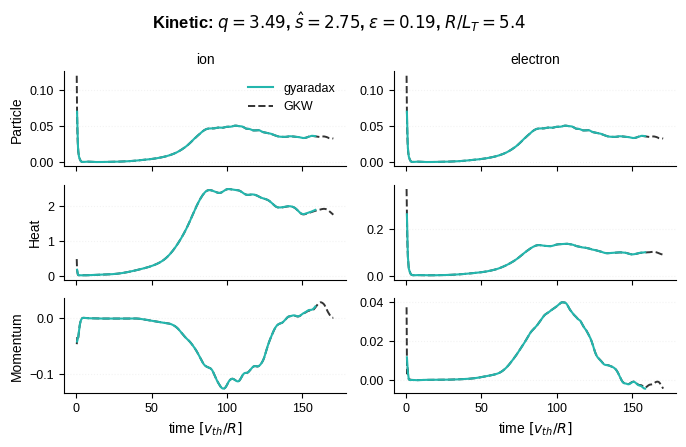

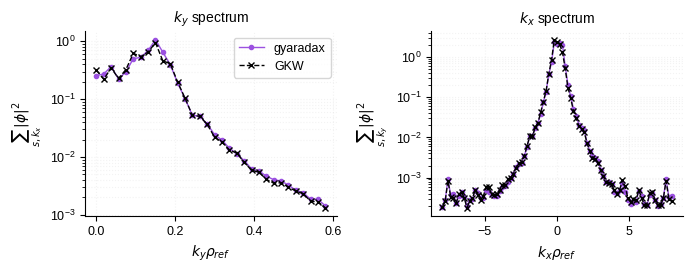

In [14]:
KINETIC_REF_DIR = "/restricteddata/ukaea/gyrokinetics/raw/kinetic_electrons"

for out_dir in kinetic_dirs:
    path = os.path.join("..", out_dir)
    case_name = out_dir.replace("validation_kinetic_", "")

    # resolve ref_dir from the yaml config (folder names don't match 1:1)
    config_path = os.path.join("..", "configs", f"{case_name}.yaml")
    if os.path.exists(config_path):
        cfg = load_config(config_path)
        ref_dir = cfg.run.data_dir
    else:
        ref_dir = os.path.join(KINETIC_REF_DIR, case_name)

    flux_path = os.path.join(path, "fluxes.npz")
    growth_path = os.path.join(path, "growth.npz")

    if not os.path.exists(flux_path) or not os.path.exists(growth_path):
        print(f"skipping {out_dir}: missing .npz files")
        continue

    # fluxes shape: (n_entries, nsp, 3) -> interleave to (6, n_entries)
    # order: [pflux_i, eflux_i, vflux_i, pflux_e, eflux_e, vflux_e]
    fluxes_data = np.load(flux_path)["fluxes"]
    sim_times = np.load(growth_path)["time"]
    sim_fluxes = fluxes_data.reshape(-1, 6).T

    ref_time = np.loadtxt(os.path.join(ref_dir, "time.dat"))[1:]
    ref_fluxes = np.loadtxt(os.path.join(ref_dir, "fluxes.dat"))[1:].T  # (6, n_ref)

    # build title from geometry scalars
    geom = load_geometry(ref_dir)
    q = float(geom["q"])
    shat = float(geom["shat"])
    eps = float(geom["eps"])
    rlt = float(np.asarray(geom["rlt"]).flat[0])
    title = (
        rf"Kinetic: $q={q:.2f}$, $\hat{{s}}={shat:.2f}$, "
        rf"$\varepsilon={eps:.2f}$, $R/L_T={rlt:.1f}$"
    )

    # all 3 fluxes, split by species (ion | electron columns)
    fig = plot_flux_trace(
        sim_times,
        sim_fluxes,
        ref_time=ref_time,
        ref_fluxes=ref_fluxes,
        labels=["Particle", "Heat", "Momentum"],
        title=title,
        n_species=2,
    )
    fig.savefig(f"figs/kinetic_fluxes_{case_name}.pdf")
    plt.show()

    # spectra if available
    kx_spec_path = os.path.join(path, "kxspec.npz")
    ky_spec_path = os.path.join(path, "kyspec.npz")
    if os.path.exists(kx_spec_path) and os.path.exists(ky_spec_path):
        kx = np.asarray(geom["kxrh"])
        ky = np.asarray(geom["krho"])

        avg_count = min(80, len(np.load(kx_spec_path)["kx_spec"]))
        kx_spec_avg = np.mean(np.load(kx_spec_path)["kx_spec"][-avg_count:], axis=0)
        ky_spec_avg = np.mean(np.load(ky_spec_path)["ky_spec"][-avg_count:], axis=0)

        ref_kx_spec, ref_ky_spec = None, None
        ref_kx_path = os.path.join(ref_dir, "kxspec")
        ref_ky_path = os.path.join(ref_dir, "kyspec")
        if os.path.exists(ref_kx_path) and os.path.exists(ref_ky_path):
            ref_kx_spec = np.mean(np.loadtxt(ref_kx_path)[-avg_count * 3 :], axis=0)
            ref_ky_spec = np.mean(np.loadtxt(ref_ky_path)[-avg_count * 3 :], axis=0)

        fig_spec = plot_spectra(
            kx=kx,
            ky=ky,
            kx_spec=kx_spec_avg,
            ky_spec=ky_spec_avg,
            ref_kx_spec=ref_kx_spec,
            ref_ky_spec=ref_ky_spec,
        )
        fig_spec.savefig(f"figs/kinetic_spectra_{case_name}.pdf")
        plt.show()